QFlow Lite — Quantum Dot Device State Classification
**Dataset:** 1 001 simulated 100×100 stability maps  
**Task:** 4-class classification — Barrier | Single Dot | Double Dot | Short Circuit  
**Models:** SVM · Random Forest · Gradient Boosting · MLP (2-layer) · MLP (4-layer) · CNN (PyTorch, optional)


1 · Imports & configuration

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets          # progress bars without tqdm dependency

# ── scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# ── PyTorch (optional) ────────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11,
                     "axes.labelsize": 10, "font.family": "DejaVu Sans"})
print("Imports complete")


C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Imports complete


2 · Configuration

In [2]:
# ── EDIT THESE IF NEEDED ─────────────────────────────────────────────────────
DATA_DIR       = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")
OUT_DIR        = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite/results")

N_SAMPLES      = 1001
RANDOM_STATE   = 42
TEST_SIZE      = 0.20     # 80/20 split
N_PCA          = 128      # PCA components per channel (reduce to 64 if slow)
CNN_EPOCHS     = 30
CNN_BATCH      = 32
# ─────────────────────────────────────────────────────────────────────────────

LABEL_NAMES = {0: "Barrier", 1: "Single Dot", 2: "Double Dot", 3: "Short Circuit"}
COLORS      = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d"]

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data dir  : {DATA_DIR}")
print(f"Output dir: {OUT_DIR}")


Data dir  : C:\Users\Lehma\AIProjects\data_qflow_lite
Output dir: C:\Users\Lehma\AIProjects\data_qflow_lite\results


In [6]:
DATA_DIRS = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")
print("Exists:", DATA_DIRS.exists())
for item in sorted(DATA_DIRS.iterdir()):
    print("  ", item.name)

Exists: True
   .DS_Store
   .ipynb_checkpoints
   20171118-123151236063.npy
   20171118-123718877110.npy
   20171118-123720973804.npy
   20171118-123722889951.npy
   20171118-123723470541.npy
   20171118-123725531133.npy
   20171118-123726080809.npy
   20171118-123726157701.npy
   20171118-123726890410.npy
   20171118-123732031617.npy
   20171118-123736470274.npy
   20171118-123755282039.npy
   20171118-123758266034.npy
   20171118-123801560100.npy
   20171118-123801636183.npy
   20171118-123804820181.npy
   20171118-123805935375.npy
   20171118-123806606588.npy
   20171118-123809190101.npy
   20171118-123813204841.npy
   20171118-123819444453.npy
   20171118-123833652194.npy
   20171118-123838503239.npy
   20171118-123840551671.npy
   20171118-123841860571.npy
   20171118-123842279218.npy
   20171118-123845802475.npy
   20171118-123849570492.npy
   20171118-123855374070.npy
   20171118-123902403990.npy
   20171118-123904932441.npy
   20171118-123913531592.npy
   20171118-123918809852

3 · Load dataset

In [10]:
DATA_DIRS = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")

# Pick the first real .npy file
files = sorted([f for f in os.listdir(DATA_DIRS) if f.endswith('.npy')])
print(f"Total .npy files: {len(files)}")

# Inspect first file
f0 = np.load(DATA_DIRS / files[0], allow_pickle=True)
print(f"\nFile      : {files[0]}")
print(f"Type      : {type(f0)}")
print(f"Shape     : {f0.shape}")
print(f"Dtype     : {f0.dtype}")

# If it's an object array (dict stored inside)
if f0.dtype == object:
    inner = f0.item()
    print(f"\nInner type: {type(inner)}")
    if isinstance(inner, dict):
        for k, v in inner.items():
            print(f"  key='{k}'  shape={getattr(v,'shape','?')}  dtype={getattr(v,'dtype','?')}")
    else:
        print("Inner value:", inner)
else:
    print(f"\nArray contents (first 5 flat values): {f0.flat[:5]}")
    if f0.ndim >= 2:
        print(f"First 2D slice shape: {f0[0].shape if f0.ndim==3 else f0.shape}")

Total .npy files: 1001

File      : 20171118-123151236063.npy
Type      : <class 'numpy.ndarray'>
Shape     : ()
Dtype     : object

Inner type: <class 'dict'>
  key='V_P1_vec'  shape=(100,)  dtype=float64
  key='physics'  shape=?  dtype=?
  key='output'  shape=?  dtype=?
  key='type'  shape=?  dtype=?
  key='V_P2_vec'  shape=(100,)  dtype=float64


In [11]:
inner = np.load(DATA_DIRS / files[0], allow_pickle=True).item()

print("=== 'type' ===")
print(repr(inner['type']))

print("\n=== 'output' ===")
out = inner['output']
print(f"  type: {type(out)}")
if isinstance(out, dict):
    for k, v in out.items():
        print(f"  key='{k}'  shape={getattr(v,'shape','?')}  dtype={getattr(v,'dtype','?')}")
else:
    print(repr(out))

print("\n=== 'physics' ===")
phy = inner['physics']
print(f"  type: {type(phy)}")
if isinstance(phy, dict):
    for k, v in phy.items():
        print(f"  key='{k}'  shape={getattr(v,'shape','?')}  dtype={getattr(v,'dtype','?')}")
else:
    print(repr(phy))

=== 'type' ===
'V_P_map'

=== 'output' ===
  type: <class 'list'>
[{'charge': [0.0], 'current': 7.570721774318194e-19, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 1.0223173043295348e-18, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 1.3904017360428418e-18, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 1.907382990878718e-18, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 2.6557474407249084e-18, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 3.584358140050789e-18, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 5.208320735640336e-18, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 7.235277235783258e-18, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 1.0148824676604988e-17, 'state': 0, 'sensor': array([0., 0.])}, {'charge': [0.0], 'current': 1.4399118399040685e-17, 'state': 0, 'sensor': array([0., 0.])}, {'charge

In [3]:
def load_dataset(data_dir):
    files = sorted([f for f in os.listdir(data_dir) 
                    if f.endswith('.npy') and not f.startswith('.')])
    
    currents, coulombs, occupancies, labels = [], [], [], []
    skipped = 0

    for fname in files:
        try:
            data = np.load(data_dir / fname, allow_pickle=True).item()
            output = data['output']   # list of 10000 dicts

            if len(output) != 10000:
                skipped += 1
                continue

            # Extract per-pixel values
            current_map  = np.array([p['current']       for p in output], dtype=np.float32).reshape(100, 100)
            sensor_map   = np.array([p['sensor'][0]     for p in output], dtype=np.float32).reshape(100, 100)
            
            # Charge occupancy: use length of charge tuple as proxy (0=barrier/short, 1=single, 2=double)
            def charge_to_float(c):
                try:
                    return float(len(c)) if hasattr(c, '__len__') else float(c)
                except:
                    return 0.0
            charge_map = np.array([charge_to_float(p['charge']) for p in output], dtype=np.float32).reshape(100, 100)

            # Label: majority state across all pixels
            states = [p['state'] for p in output]
            label  = int(max(set(states), key=states.count))

            currents.append(current_map)
            coulombs.append(sensor_map)
            occupancies.append(charge_map)
            labels.append(label)

        except Exception as e:
            print(f"  WARN {fname}: {e}")
            skipped += 1

    if skipped:
        print(f"Skipped {skipped} files.")

    current   = np.stack(currents)
    coulomb   = np.stack(coulombs)
    occupancy = np.stack(occupancies)
    labels    = np.array(labels, dtype=np.int64)

    print(f"\nLoaded {len(labels)} samples")
    print(f"Map shape per sample: {current[0].shape}")
    print("\nClass distribution:")
    for k, name in LABEL_NAMES.items():
        n = (labels == k).sum()
        bar = "█" * int(n / len(labels) * 40)
        print(f"  {name:<14} ({k})  {n:>4} samples  {bar}")
    
    return current, coulomb, occupancy, labels

current, coulomb, occupancy, labels = load_dataset(DATA_DIR)


Loaded 1001 samples
Map shape per sample: (100, 100)

Class distribution:
  Barrier        (0)    18 samples  
  Single Dot     (1)   756 samples  ██████████████████████████████
  Double Dot     (2)   227 samples  █████████
  Short Circuit  (3)     0 samples  


Visualise sample stability maps

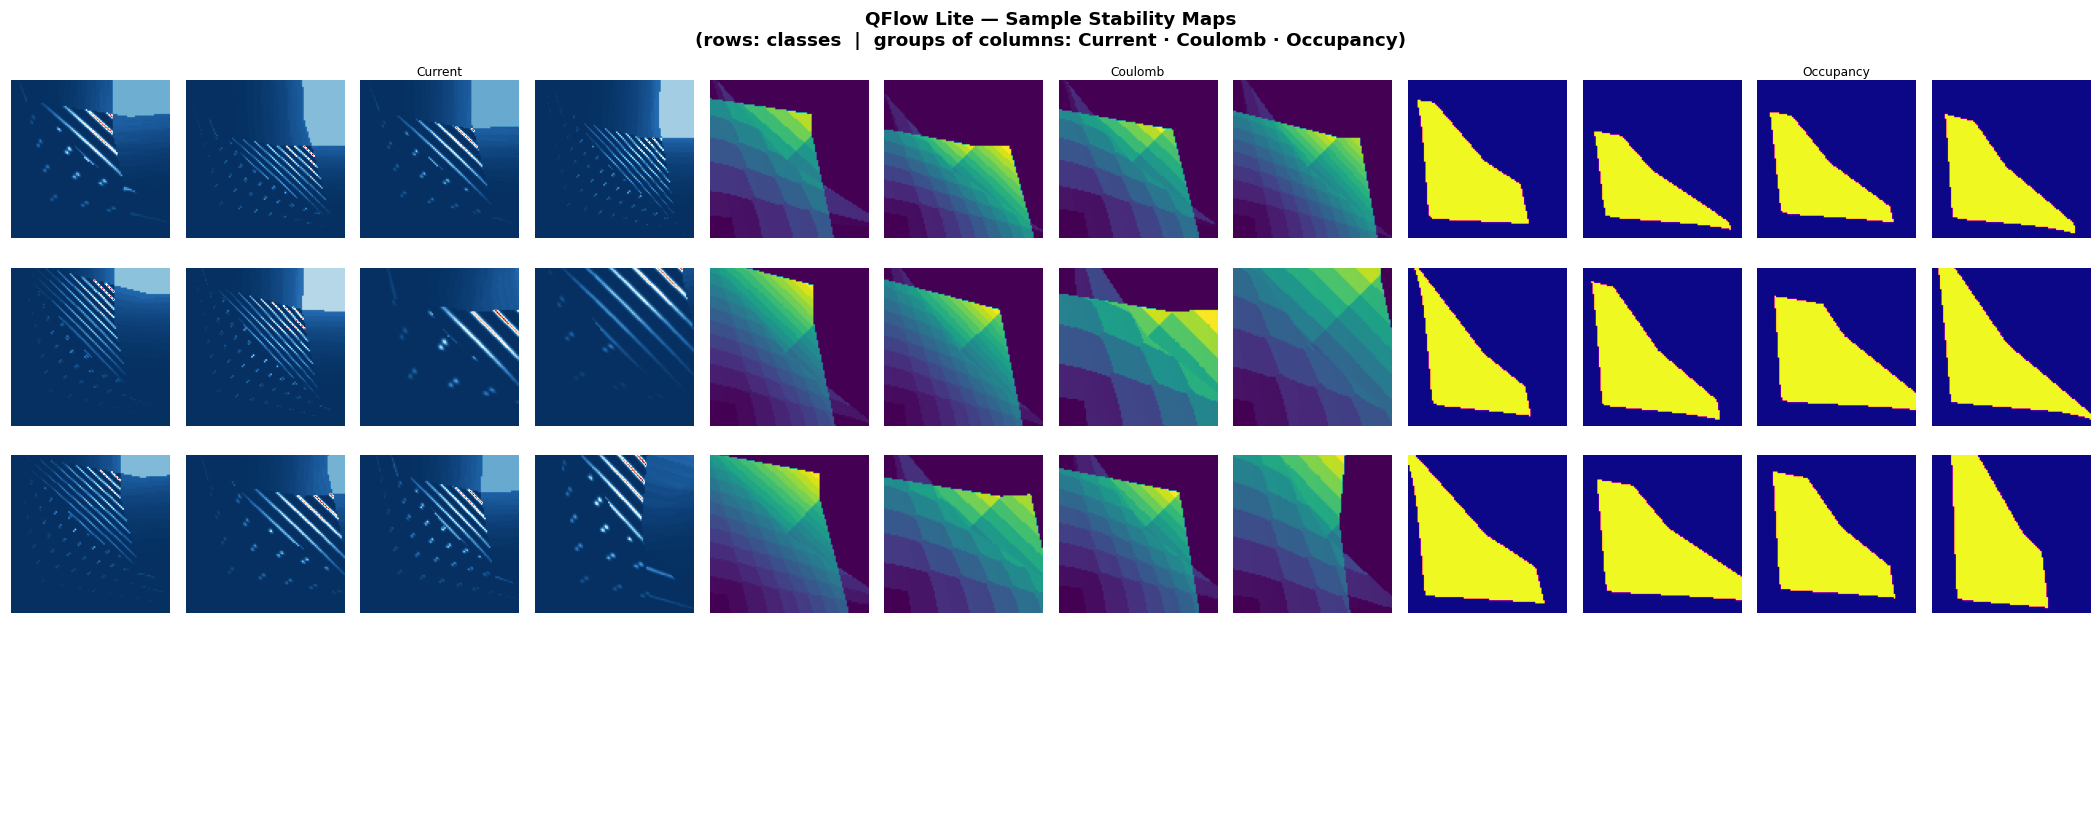

In [4]:
def plot_samples(current, coulomb, occupancy, labels, n_per_class=4):
    """Grid: rows = classes, cols = channels × examples."""
    channels   = [("Current",   current,   "RdBu_r"),
                  ("Coulomb",   coulomb,   "viridis"),
                  ("Occupancy", occupancy, "plasma")]
    n_cls      = len(LABEL_NAMES)
    cols_total = len(channels) * n_per_class

    fig, axes = plt.subplots(n_cls, cols_total,
                             figsize=(cols_total * 1.6, n_cls * 1.9),
                             squeeze=False)
    fig.suptitle("QFlow Lite — Sample Stability Maps\n"
                 "(rows: classes  |  groups of columns: Current · Coulomb · Occupancy)",
                 fontsize=12, fontweight="bold")

    for row, (cls_idx, cls_name) in enumerate(LABEL_NAMES.items()):
        sample_idx = np.where(labels == cls_idx)[0][:n_per_class]
        for ch_col, (ch_name, ch_data, cmap) in enumerate(channels):
            for s, idx in enumerate(sample_idx):
                col = ch_col * n_per_class + s
                ax  = axes[row, col]
                ax.imshow(ch_data[idx], cmap=cmap, origin="lower")
                ax.axis("off")
                if s == 0:
                    ax.set_ylabel(cls_name, fontsize=8, rotation=90, labelpad=4)
                if row == 0 and s == n_per_class // 2:
                    ax.set_title(ch_name, fontsize=8, pad=3)
            # fill empty columns
            for s in range(len(sample_idx), n_per_class):
                axes[row, ch_col * n_per_class + s].axis("off")

    plt.tight_layout()
    plt.show()

plot_samples(current, coulomb, occupancy, labels)


## 5 · Feature engineering
Each of the 3 channels contributes **14 statistical descriptors** + **128 PCA components** → 426-dim flat vector fed to classical models.

In [14]:
def channel_stats(maps):
    """14 descriptors per sample: mean, std, min, max, skewness, 9 percentiles."""
    N    = len(maps)
    flat = maps.reshape(N, -1)
    p    = np.percentile(flat, [10,20,30,40,50,60,70,80,90], axis=1).T
    mu   = flat.mean(1, keepdims=True)
    sg   = flat.std(1,  keepdims=True)
    skew = ((flat - mu)**3).mean(1, keepdims=True) / (sg**3 + 1e-8)
    return np.hstack([mu, sg, flat.min(1,keepdims=True),
                      flat.max(1,keepdims=True), skew, p])   # (N,14)


def build_flat_features(current, coulomb, occupancy, n_pca=N_PCA):
    """Return (N, 42 + 3*n_pca) feature matrix."""
    N     = len(current)
    stats = np.hstack([channel_stats(current),
                       channel_stats(coulomb),
                       channel_stats(occupancy)])   # (N, 42)

    pca_parts = []
    for ch, name in zip([current, coulomb, occupancy],
                        ["current", "coulomb", "occupancy"]):
        flat   = ch.reshape(N, -1)
        flat_s = StandardScaler().fit_transform(flat)
        k      = min(n_pca, flat_s.shape[1], N - 1)
        pca_parts.append(PCA(k, random_state=RANDOM_STATE).fit_transform(flat_s))
        print(f"  PCA({name}): {k} components")

    return np.hstack([stats] + pca_parts)


def build_2d_features(current, coulomb, occupancy):
    """Stack channels → (N, 3, 100, 100) for CNN."""
    return np.stack([current, coulomb, occupancy], axis=1)


print("Building flat features …")
X_flat = build_flat_features(current, coulomb, occupancy)
X_2d   = build_2d_features(current, coulomb, occupancy)
print(f"\nFlat feature matrix : {X_flat.shape}")
print(f"2D tensor           : {X_2d.shape}")


Building flat features …
  PCA(current): 128 components
  PCA(coulomb): 128 components
  PCA(occupancy): 128 components

Flat feature matrix : (1001, 426)
2D tensor           : (1001, 3, 100, 100)


## 6 · PCA scatter — are classes separable?

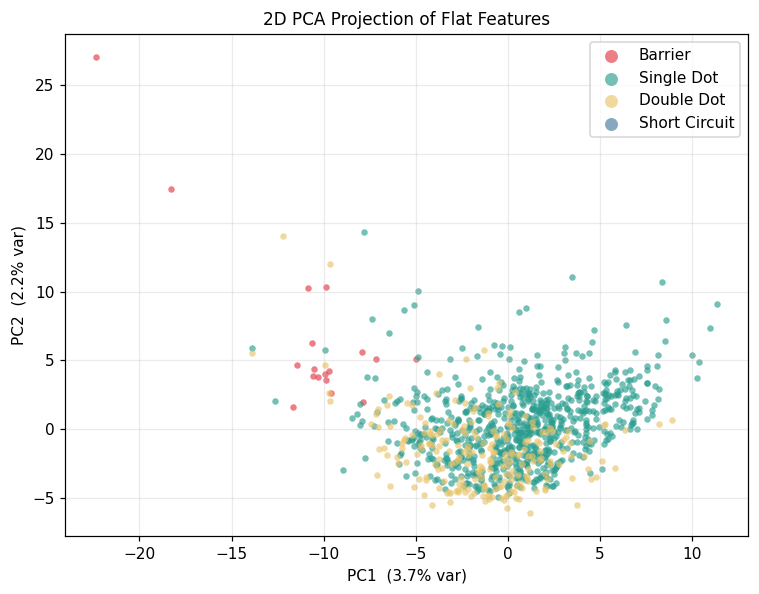

Saved → results/pca_scatter.png


In [15]:
pca2   = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca2.fit_transform(StandardScaler().fit_transform(X_flat))

fig, ax = plt.subplots(figsize=(7, 5.5))
for k, name in LABEL_NAMES.items():
    mask = labels == k
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=COLORS[k], label=name, alpha=0.65, s=18, linewidths=0)

ax.set_xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("2D PCA Projection of Flat Features")
ax.legend(markerscale=2)
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUT_DIR / "pca_scatter.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → results/pca_scatter.png")


7 · Train / test split